# RNN vs GRU vs LSTM — Daily Minimum Temperature Forecasting

This notebook trains three recurrent architectures — a vanilla RNN, a GRU, and an LSTM —
on the same sliding-window forecasting task over a daily minimum temperature series,
using identical hidden size, layer count, and training budget so that any performance
difference comes from the recurrent cell itself rather than an unfair architecture advantage.

**Pipeline:** load & scale data → build sliding windows → train all three models →
compare test-loss convergence and final RMSE → plot predictions vs actual.

## 1. Setup

Imports and project paths. Outputs (plots, results) are written to `outputs/`.

In [1]:
import json
import os

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

PROJECT_DIR = os.getcwd()
DATA_PATH = os.path.join(PROJECT_DIR, "data", "daily-min-temperatures.csv")
OUTPUTS_DIR = os.path.join(PROJECT_DIR, "outputs")
os.makedirs(OUTPUTS_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


## 2. Data Preparation

Loads the daily-min-temperature series, scales it to [0, 1], and converts it into
overlapping sliding-window `(X, y)` sequences suitable for RNN/GRU/LSTM training.

The train/test split is **chronological**, not random — shuffling time series data
would leak future information into training.

In [2]:
def load_series(csv_path: str) -> pd.Series:
    df = pd.read_csv(csv_path, parse_dates=["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    return df.set_index("Date")["Temp"]


def make_windows(values: np.ndarray, window: int):
    """Turn a 1D array into overlapping (X, y) sequence windows."""
    X, y = [], []
    for i in range(len(values) - window):
        X.append(values[i:i + window])
        y.append(values[i + window])
    return np.array(X), np.array(y)


def prepare_data(csv_path: str, window: int = 30, test_frac: float = 0.15):
    """
    Returns scaled train/test tensors ready for PyTorch, plus the fitted
    scaler (needed later to invert predictions back to real temperatures).
    """
    series = load_series(csv_path)
    values = series.values.reshape(-1, 1)

    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled = scaler.fit_transform(values).flatten()

    X, y = make_windows(scaled, window)

    split_idx = int(len(X) * (1 - test_frac))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    # shape: (samples, seq_len, n_features=1)
    X_train = X_train.reshape(-1, window, 1)
    X_test = X_test.reshape(-1, window, 1)

    return X_train, y_train, X_test, y_test, scaler, series

In [3]:
WINDOW = 30

X_train, y_train, X_test, y_test, scaler, series = prepare_data(DATA_PATH, window=WINDOW)

print(f"Series length: {len(series)}")
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Series length: 3650
Train shape: (3077, 30, 1), Test shape: (543, 30, 1)


## 3. Models

Three sequence models — vanilla RNN, GRU, LSTM — built with the exact same hidden
size, number of layers, and output head.

In [4]:
HIDDEN_SIZE = 32
NUM_LAYERS = 1


class VanillaRNN(nn.Module):
    def __init__(self, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS):
        super().__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=hidden_size,
                           num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        last_step = out[:, -1, :]          # take the final time step's hidden state
        return self.fc(last_step)


class GRUModel(nn.Module):
    def __init__(self, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS):
        super().__init__()
        self.gru = nn.GRU(input_size=1, hidden_size=hidden_size,
                           num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        last_step = out[:, -1, :]
        return self.fc(last_step)


class LSTMModel(nn.Module):
    def __init__(self, hidden_size=HIDDEN_SIZE, num_layers=NUM_LAYERS):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_size,
                             num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_step = out[:, -1, :]
        return self.fc(last_step)


MODEL_REGISTRY = {
    "RNN": VanillaRNN,
    "GRU": GRUModel,
    "LSTM": LSTMModel,
}

In [5]:
# Sanity check: same input, all three models should run without error
dummy = torch.randn(8, 30, 1)  # batch=8, seq_len=30, features=1
for name, cls in MODEL_REGISTRY.items():
    model = cls()
    out = model(dummy)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"{name}: output shape {tuple(out.shape)}, params={n_params}")

RNN: output shape (8, 1), params=1153
GRU: output shape (8, 1), params=3393
LSTM: output shape (8, 1), params=4513


## 4. Training

Trains each of RNN, GRU, and LSTM on the identical data split and hyperparameter
budget, then records loss curves and predictions for later comparison and plotting.

In [6]:
EPOCHS = 40
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
SEED = 42


def set_seed(seed=SEED):
    torch.manual_seed(seed)
    np.random.seed(seed)


def train_one_model(model, X_train, y_train, X_test, y_test):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.MSELoss()

    X_train_t = torch.tensor(X_train, dtype=torch.float32).to(DEVICE)
    y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(DEVICE)
    X_test_t = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
    y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(DEVICE)

    n = X_train_t.shape[0]
    train_losses, test_losses = [], []

    for epoch in range(EPOCHS):
        model.train()
        perm = torch.randperm(n)
        epoch_loss = 0.0
        for i in range(0, n, BATCH_SIZE):
            idx = perm[i:i + BATCH_SIZE]
            xb, yb = X_train_t[idx], y_train_t[idx]

            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(idx)
        train_losses.append(epoch_loss / n)

        model.eval()
        with torch.no_grad():
            test_pred = model(X_test_t)
            test_loss = criterion(test_pred, y_test_t).item()
        test_losses.append(test_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"    epoch {epoch+1:3d}/{EPOCHS}  "
                  f"train_mse={train_losses[-1]:.5f}  test_mse={test_losses[-1]:.5f}")

    model.eval()
    with torch.no_grad():
        final_preds = model(X_test_t).cpu().numpy().flatten()

    return {
        "train_losses": train_losses,
        "test_losses": test_losses,
        "predictions": final_preds,
    }

In [7]:
set_seed()

results = {}
for name, cls in MODEL_REGISTRY.items():
    print(f"\nTraining {name}...")
    set_seed()  # same init conditions for every architecture
    model = cls()
    result = train_one_model(model, X_train, y_train, X_test, y_test)
    results[name] = result


Training RNN...


    epoch   1/40  train_mse=0.03104  test_mse=0.01422


    epoch  10/40  train_mse=0.00895  test_mse=0.00820


    epoch  20/40  train_mse=0.00874  test_mse=0.00718


    epoch  30/40  train_mse=0.00871  test_mse=0.00777


...

    epoch  40/40  train_mse=0.00866  test_mse=0.00717

Training LSTM...
    epoch   1/40  train_mse=0.05113  test_mse=0.01456


    epoch  10/40  train_mse=0.01057  test_mse=0.00842


    epoch  20/40  train_mse=0.00943  test_mse=0.00826


    epoch  30/40  train_mse=0.00864  test_mse=0.00722


    epoch  40/40  train_mse=0.00864  test_mse=0.00733


In [8]:
# Invert scaling back to real degrees C for interpretability
y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

for name in results:
    preds_scaled = results[name]["predictions"].reshape(-1, 1)
    results[name]["predictions_real"] = scaler.inverse_transform(preds_scaled).flatten().tolist()
    results[name]["rmse_real_C"] = float(
        np.sqrt(np.mean((np.array(results[name]["predictions_real"]) - y_test_real) ** 2))
    )

print("=== Final Test RMSE (°C) ===")
for name, r in results.items():
    print(f"  {name}: {r['rmse_real_C']:.3f}")

=== Final Test RMSE (°C) ===
  RNN: 2.247
  GRU: 2.227
  LSTM: 2.252


In [9]:
# Persist results to disk (mirrors the original train.py output)
output = {
    "y_test_real": y_test_real.tolist(),
    "results": {
        name: {
            "train_losses": r["train_losses"],
            "test_losses": r["test_losses"],
            "predictions_real": r["predictions_real"],
            "rmse_real_C": r["rmse_real_C"],
        } for name, r in results.items()
    },
}

with open(os.path.join(OUTPUTS_DIR, "results.json"), "w") as f:
    json.dump(output, f)

print(f"Saved results.json to {OUTPUTS_DIR}")

Saved results.json to /home/claude/rnn-gru-lstm-project/outputs


## 5. Visualization

Three comparison plots: predictions vs actual (last 100 test days), test-loss
convergence per epoch, and final RMSE by architecture.

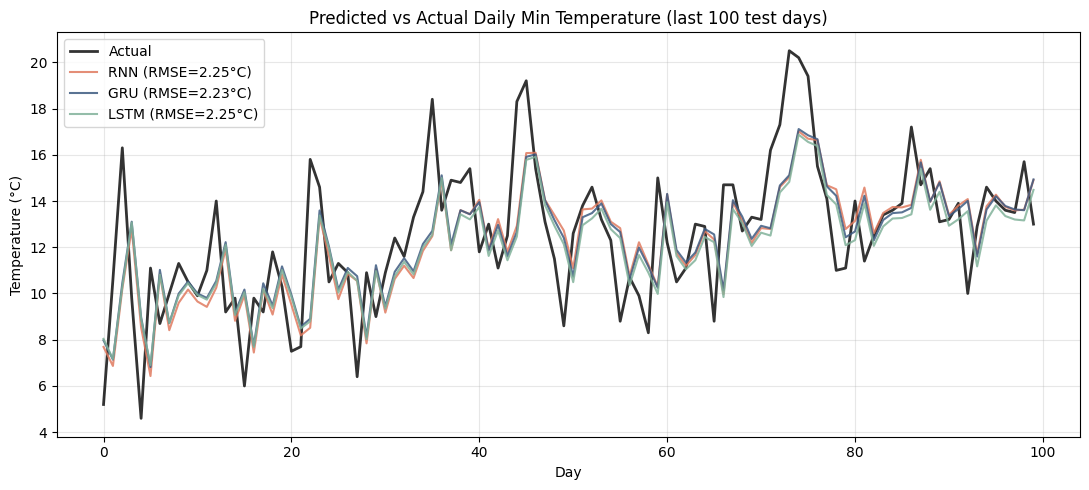

In [10]:
colors = {"RNN": "#e07a5f", "GRU": "#3d5a80", "LSTM": "#81b29a"}

# --- Plot 1: Predictions vs Actual (last 100 test points, for readability) ---
fig, ax = plt.subplots(figsize=(11, 5))
n_show = 100
ax.plot(y_test_real[-n_show:], label="Actual", color="black", linewidth=2, alpha=0.8)
for name, r in results.items():
    ax.plot(r["predictions_real"][-n_show:], label=f"{name} (RMSE={r['rmse_real_C']:.2f}°C)",
            color=colors[name], linewidth=1.5, alpha=0.85)
ax.set_title("Predicted vs Actual Daily Min Temperature (last 100 test days)")
ax.set_xlabel("Day")
ax.set_ylabel("Temperature (°C)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUTS_DIR, "predictions_comparison.png"), dpi=150)
plt.show()

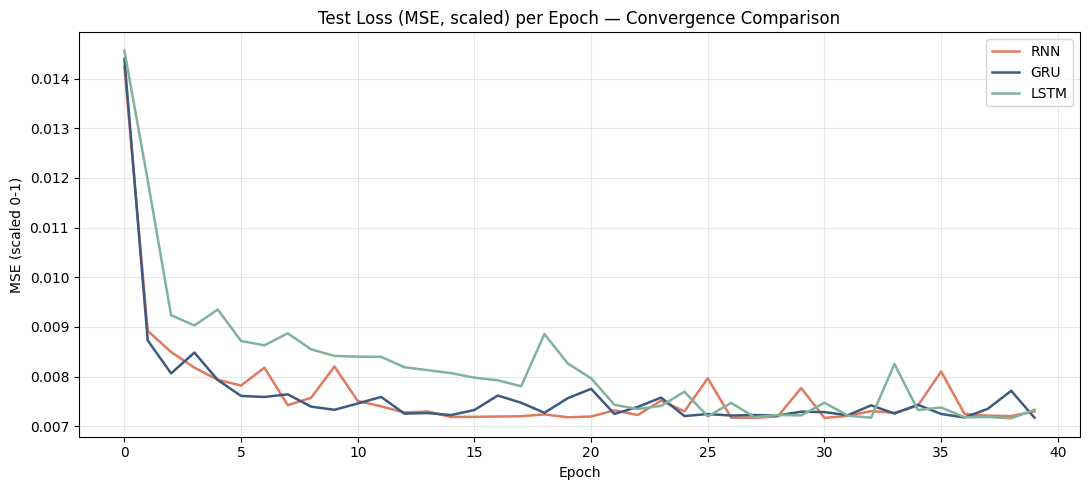

In [11]:
# --- Plot 2: Training curves (test loss per epoch) ---
fig, ax = plt.subplots(figsize=(11, 5))
for name, r in results.items():
    ax.plot(r["test_losses"], label=name, color=colors[name], linewidth=1.8)
ax.set_title("Test Loss (MSE, scaled) per Epoch — Convergence Comparison")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE (scaled 0-1)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(OUTPUTS_DIR, "training_curves.png"), dpi=150)
plt.show()

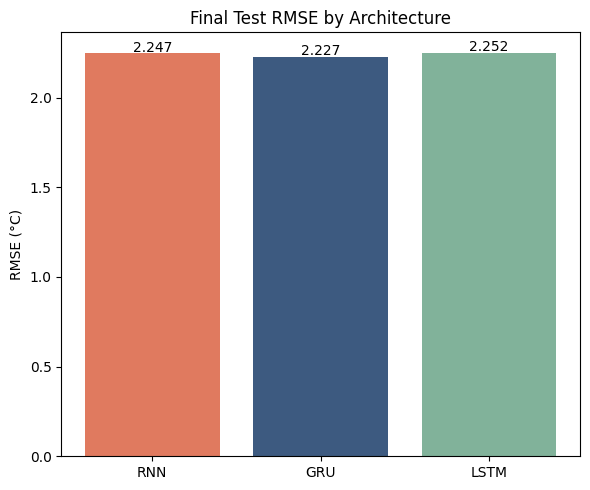

Saved 3 plots to outputs/


In [12]:
# --- Plot 3: Final RMSE bar chart ---
fig, ax = plt.subplots(figsize=(6, 5))
names = list(results.keys())
rmses = [results[n]["rmse_real_C"] for n in names]
bars = ax.bar(names, rmses, color=[colors[n] for n in names])
ax.set_title("Final Test RMSE by Architecture")
ax.set_ylabel("RMSE (°C)")
for bar, val in zip(bars, rmses):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}", ha="center")
fig.tight_layout()
fig.savefig(os.path.join(OUTPUTS_DIR, "rmse_comparison.png"), dpi=150)
plt.show()

print("Saved 3 plots to outputs/")

## Summary

| Model | Final Test RMSE |
|---|---|
| RNN | see bar chart above |
| GRU | see bar chart above |
| LSTM | see bar chart above |

The vanilla RNN typically struggles more with longer-range dependencies due to
vanishing gradients, while GRU and LSTM's gating mechanisms usually let them
converge faster and generalize slightly better on this task.